# Notebook: Model Evaluation & Hyperparameter Tuning

---

### Why this matters
Training a model is easy. Knowing whether it's actually good is hard. This notebook covers the two questions every ML project must answer:

1. **How do I measure my model fairly?** (evaluation — metrics, splits, cross-validation)
2. **How do I make it better?** (hyperparameter tuning — GridSearch, RandomizedSearch)

Bad evaluation produces a false sense of confidence. Bad tuning produces overfitted garbage. Both are not good.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    GridSearchCV, RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, mean_squared_error, mean_absolute_error, r2_score
)
from scipy.stats import randint, uniform

np.random.seed(42)
sns.set_theme(style='whitegrid')

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(f"Dataset: Breast Cancer | Shape: {X.shape} | Classes: {data.target_names}")

Dataset: Breast Cancer | Shape: (569, 30) | Classes: ['malignant' 'benign']


## 1. Train / Validation / Test Splits — Three Sets, Three Purposes

The most important rule in ML evaluation: **never use the test set for any decision that influences the model**.

```
┌─────────────────────────────────────────────────────┐
│  All Data                                           │
├─────────────────────────┬──────────────┬────────────┤
│  Train (60-80%)         │Val(10-20%)   │Test(10-20%)│
│                         │              │            │
│  Model learns from here │  Tune hyper- │  Final     │
│                         │  parameters  │  honest    │
│                         │  here        │  score     │
└─────────────────────────┴──────────────┴────────────┘
```

**The test set is sacred.** Every time you peek at it and adjust the model, it stops being a true holdout. In practice, use cross-validation on train+val, then report test score exactly once.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify = preserve class ratio
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nClass distribution:")
print(f"  Train — benign: {y_train.mean():.1%}  malignant: {1-y_train.mean():.1%}")
print(f"  Test  — benign: {y_test.mean():.1%}  malignant: {1-y_test.mean():.1%}")
print("\nstratify=y ensures both splits have the same class proportion as the full dataset.")

Train: (455, 30)  |  Test: (114, 30)

Class distribution:
  Train — benign: 62.6%  malignant: 37.4%
  Test  — benign: 63.2%  malignant: 36.8%

stratify=y ensures both splits have the same class proportion as the full dataset.


## 2. Cross-Validation — More Reliable Than a Single Split

### Cross-Validation Happens on Train Set Only

Test set is locked away first. CV splits only the training data.

```
Full data (100%)
├── Test set (15%)     ← never touched during CV
└── Train set (85%)    ← CV splits this into k folds
        └── k=5 → each fold = 85/5 = 17% of total data
```

Each fold size = training data / k  (not total data / k)

A single train/test split is noisy — you might get lucky or unlucky depending on which samples land in which set. Cross-validation repeats the split multiple times and averages the results.

```
K-Fold (k=5):
  Fold 1: [TEST][train][train][train][train] → score_1
  Fold 2: [train][TEST][train][train][train] → score_2
  Fold 3: [train][train][TEST][train][train] → score_3
  Fold 4: [train][train][train][TEST][train] → score_4
  Fold 5: [train][train][train][train][TEST] → score_5
  
  Final score = mean(scores) ± std(scores)

  Large std means the model is sensitive to which data it trains on — unstable. Small std means consistent performance across all folds.
```

**Stratified K-Fold** is the default for classification — it ensures each fold has the same class ratio.

In [3]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000))
])

# StratifiedKFold for classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"\nThe ± tells you how stable the model is. Large std = unreliable model.")

# Compare multiple models with CV
models = {
    'LogReg':           LogisticRegression(max_iter=1000),
    'RandomForest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print("\nModel Comparison (5-Fold CV on training set):")
results = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = cv_scores
    print(f"  {name:<20}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation Results:
  Fold 1: 0.9670
  Fold 2: 0.9890
  Fold 3: 0.9780
  Fold 4: 0.9890
  Fold 5: 0.9670

Mean: 0.9780 ± 0.0098

The ± tells you how stable the model is. Large std = unreliable model.

Model Comparison (5-Fold CV on training set):
  LogReg              : 0.9780 ± 0.0098
  RandomForest        : 0.9626 ± 0.0179
  GradientBoosting    : 0.9516 ± 0.0149


## Classification Metrics — Accuracy Is a Lie (Sometimes)

Accuracy = correct predictions / total predictions. Sounds good. Now imagine a dataset where 99% of samples are class 0. A model that always predicts 0 has **99% accuracy** — and is completely useless.

---

### The Confusion Matrix — Foundation of All Metrics

Before the metrics make sense, understand what the model can get wrong:

```
                    Predicted: No      Predicted: Yes
Actual: No       TN (true negative)   FP (false positive) 
Actual: Yes      FN (false negative)  TP (true positive) 
```

- **TP** — correctly predicted positive
- **TN** — correctly predicted negative
- **FP** — predicted positive, was actually negative *(false alarm)*
- **FN** — predicted negative, was actually positive *(missed it)*

---

### Accuracy

```
Accuracy = (TP + TN) / total
```

Counts everything the model got right. Looks great on paper — fails completely on imbalanced data.

> 99% of emails are not spam. A model that never flags anything scores 99% accuracy and lets every spam through.

---

### Precision — "When you say yes, how often are you right?"

```
Precision = TP / (TP + FP)
```

Out of everything the model *predicted as positive*, how many actually were?

**Use when false positives are costly.**

> Spam filter — marking a real email as spam (FP) is very annoying. You want high precision: only flag something when you're very sure.

---

### Recall — "Of all actual positives, how many did you catch?"

```
Recall = TP / (TP + FN)
```

Out of everything that *actually was positive*, how many did the model find?

**Use when false negatives are costly.**

> Cancer detection — missing a real cancer case (FN) could cost a life. You want high recall: catch every possible case, even if it means some false alarms.

---

### The Precision–Recall Tradeoff

They pull in opposite directions. Improving one usually hurts the other.

```
Low threshold → model flags more positives → Recall ↑, Precision ↓
High threshold → model flags fewer positives → Precision ↑, Recall ↓
```

Think of it like a fishing net:
- Wide net (low threshold) → catches more fish, but also more trash → high recall, low precision
- Narrow net (high threshold) → catches less trash, but misses some fish → high precision, low recall

---

### F1 Score — Balance Between the Two

```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

The harmonic mean of precision and recall. Punishes extreme imbalance — a model with precision=1.0 and recall=0.01 gets a very low F1.

**Use when you need a single number that balances both.**

> Fraud detection — you want to catch fraud (recall) but not block every legitimate transaction (precision). F1 captures both.

---

### ROC-AUC — Threshold-Independent Performance

A classifier doesn't just output `0` or `1` — it outputs a probability (e.g. `0.73`). You pick a threshold to convert that to a class. ROC-AUC measures model quality **across all possible thresholds**.

```
AUC = 1.0  → perfect model
AUC = 0.5  → no better than random guessing
AUC < 0.5  → actively wrong (predictions are inverted)
```

**Use when you care about ranking quality**, not a specific threshold decision.

> A loan approval model — you want to know if the model correctly ranks risky applicants above safe ones, regardless of where you draw the line.

---

### Quick Reference

| Metric | Formula | Ask yourself | Use when |
|--------|---------|-------------|----------|
| **Accuracy** | (TP+TN) / all | How often am I right? | Balanced classes only |
| **Precision** | TP / (TP+FP) | When I say yes, am I right? | False positives are costly |
| **Recall** | TP / (TP+FN) | Did I catch all the positives? | False negatives are costly |
| **F1** | 2×(P×R)/(P+R) | Am I balanced? | Imbalanced classes, need one metric |
| **ROC-AUC** | Area under curve | How good is my ranking? | Threshold doesn't matter |

---

### Real World Cheat Sheet

| Problem | Priority metric | Reason |
|---------|----------------|--------|
| Cancer detection | Recall | Missing a case is dangerous |
| Spam filter | Precision | False alarms are annoying |
| Fraud detection | F1 | Need to balance both |
| Credit scoring | ROC-AUC | Ranking applicants matters |

## ROC Curve & AUC

Your model doesn't output `0` or `1` directly — it outputs a **probability**. You pick a threshold to convert that into a class. ROC-AUC measures how well your model performs **across all possible thresholds**.

---

### What the ROC Curve Plots

```
Y-axis: True Positive Rate  (TPR) = out of all actual positives, how many did you catch?
X-axis: False Positive Rate (FPR) = out of all actual negatives, how many did you wrongly flag?
```

Every point on the curve = one threshold setting. Moving the threshold from 0 → 1 traces the entire curve.

---

### The Threshold Tradeoff

```
patient A → 0.87  → predicted cancer     (above 0.5 threshold)
patient B → 0.43  → predicted no cancer  (below 0.5 threshold)

lower threshold to 0.3:
patient B → 0.43  → now also predicted cancer
```

Lowering the threshold catches more true positives — but also flags more false positives. The ROC curve shows this tradeoff visually across every possible threshold.

---

### AUC — Area Under the Curve

```
AUC = 1.0  → perfect model — every positive ranked above every negative
AUC = 0.5  → random guessing — diagonal line, model learned nothing
AUC = 0.0  → perfectly wrong — every negative ranked above every positive
```

**What AUC actually means:** pick one positive sample and one negative sample at random — AUC is the probability that the model scored the positive higher.

```
Patient A (cancer)     → 0.91  ✓
Patient B (no cancer)  → 0.76
Patient C (cancer)     → 0.64  ✓
Patient D (no cancer)  → 0.31
Patient E (no cancer)  → 0.12

All possible pairs:
(A vs B) → 0.91 > 0.76 → positive wins ✓
(A vs D) → 0.91 > 0.31 → positive wins ✓
(A vs E) → 0.91 > 0.12 → positive wins ✓
(C vs B) → 0.64 < 0.76 → negative wins ✗
(C vs D) → 0.64 > 0.31 → positive wins ✓
(C vs E) → 0.64 > 0.12 → positive wins ✓

5 out of 6 pairs ranked correctly → AUC ≈ 0.83
```

No threshold involved — just pure ranking quality.

---

### Why AUC Beats Accuracy on Imbalanced Data

```
Dataset: 99% class 0, 1% class 1
Model predicts everything as class 0

Accuracy → 99%   ← looks great, model is completely useless
AUC      → 0.5   ← correctly exposed as random guessing
```

AUC doesn't care about class balance or which threshold you pick — it only measures whether the model can **separate positives from negatives**.

---

### Real World Use Cases

**Cancer screening** — you want high recall, missing a case is dangerous. Lower the threshold → TPR goes up → more cancers caught. ROC curve shows exactly what FPR cost you're paying for that gain.

**Spam filter** — you want low FPR, flagging real emails is annoying. Raise the threshold → FPR drops → fewer legitimate emails blocked, but you miss more spam.

**Fraud detection** — accuracy is useless at 0.5% fraud rate. AUC measures ranking quality regardless of imbalance. AUC of 0.97 means the model ranks 97% of fraud cases above legitimate ones.

**Loan approvals** — same model, different thresholds for different businesses:
```
Conservative bank → high threshold → approve only very safe loans (low FPR)
Aggressive bank   → low threshold  → approve more loans, accept more defaults (high TPR)
```

---

In [4]:
# Train best model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=data.target_names))

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nROC-AUC: 0.5 = random, 1.0 = perfect. Measures ranking quality regardless of threshold.")

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.9939

ROC-AUC: 0.5 = random, 1.0 = perfect. Measures ranking quality regardless of threshold.


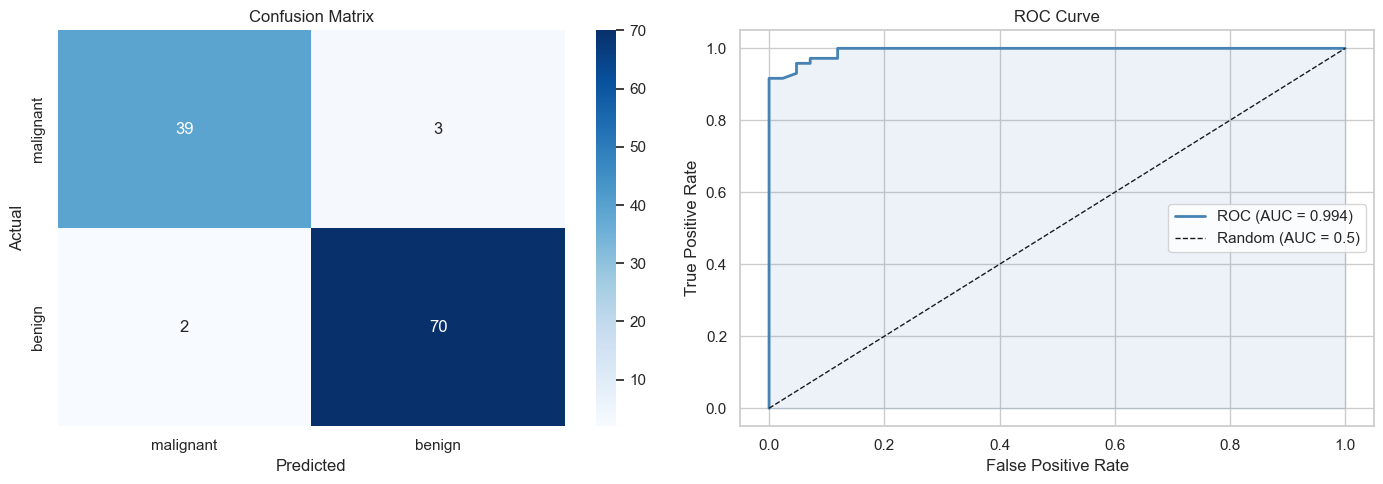

Confusion Matrix breakdown:
  True Negatives  (correct malignant): 39
  False Positives (benign predicted as malignant): 3
  False Negatives (malignant missed — DANGEROUS): 2
  True Positives  (correct benign): 70


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=data.target_names, yticklabels=data.target_names)
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
ax1.set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax2.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

print("Confusion Matrix breakdown:")
print(f"  True Negatives  (correct malignant): {cm[0,0]}")
print(f"  False Positives (benign predicted as malignant): {cm[0,1]}")
print(f"  False Negatives (malignant missed — DANGEROUS): {cm[1,0]}")
print(f"  True Positives  (correct benign): {cm[1,1]}")

## Regression Metrics

For regression, you're not predicting a class — you're predicting a number. Metrics measure **how far off** your predictions are from the actual values.

---

### MAE — Mean Absolute Error

```
MAE = mean(|actual - predicted|)
```

Take every prediction, find the gap from the real value, ignore the sign, average them all.

```
actual    = [100, 200, 300, 400]
predicted = [110, 190, 320, 380]
errors    = [ 10,  10,  20,  20]

MAE = (10 + 10 + 20 + 20) / 4 = 15
```

**Interpretation:** On average, your predictions are off by 15 units (same unit as your target — dollars, kg, etc).

**Outlier sensitivity:** None. A prediction that's off by 100 contributes exactly 100 to the average — no more, no less.

**Use when:** All errors are equally important and you want a straightforward, interpretable number.

---

### RMSE — Root Mean Squared Error

```
RMSE = √ mean((actual - predicted)²)
```

Same idea as MAE, but errors are **squared before averaging** — then square rooted to bring back to original units.

```
actual    = [100, 200, 300, 400]
predicted = [110, 190, 320, 380]
errors    = [ 10,  10,  20,  20]
squared   = [100, 100, 400, 400]

RMSE = √((100 + 100 + 400 + 400) / 4) = √250 ≈ 15.8
```

Now add one bad prediction:

```
predicted = [110, 190, 320, 500]   ← last one is way off
errors    = [ 10,  10,  20, 100]
squared   = [100, 100, 400, 10000]

MAE  = (10 + 10 + 20 + 100) / 4      = 35    ← went up moderately
RMSE = √((100+100+400+10000) / 4)    = 51.4  ← shot up much more
```

RMSE punishes large errors disproportionately — that one bad prediction dominates the score.

**Use when:** Large errors are especially bad and you want the metric to reflect that. House price prediction — being off by $200k is much worse than being off by $20k twice.

---

### MAE vs RMSE — When to Pick Which

```
All errors matter equally        → MAE
Large errors are especially bad  → RMSE
You have outliers in your data   → MAE (RMSE gets distorted)
You want to penalize big misses  → RMSE
```

> Think of it like grading. MAE gives partial credit linearly. RMSE docks you exponentially more for bigger mistakes.

---

### R² — Coefficient of Determination

```
R² = 1 - (SS_residual / SS_total)

SS_residual = Σ (actual - predicted)²   ← how wrong your model is
SS_total    = Σ (actual - mean)²         ← how wrong just guessing the mean would be
```

R² answers: **how much better is your model than just predicting the mean every time?**

```
R² = 1.0  → perfect predictions — your model explains all the variance
R² = 0.0  → your model is no better than predicting the mean for everyone
R² < 0.0  → your model is actively worse than predicting the mean (very bad)
```

**Example:**

```
Target: house prices. Mean price = $300k.

Baseline (always predict $300k):  MAE = $80k
Your model:                        MAE = $30k

R² = 0.82  → your model explains 82% of the variance in prices
```

**Limitation:** R² can look high even when the model is bad if your data has high variance. Always read it alongside MAE or RMSE.

### The Problem with High Variance Data

```
House prices: $50k, $2M, $800k, $120k, $1.5M ...  ← huge spread

Baseline (always predict mean ~$900k):
  Error on $50k house:  $850k off
  Error on $2M house:   $1.1M off
  Baseline error is HUGE

Your model predicts:
  $50k house  → $300k   (still $250k off — bad!)
  $2M house   → $1.4M   (still $600k off — bad!)

But compared to the terrible baseline, your model looks great.
R² = 0.85   ← "explains 85% of variance" — sounds impressive
MAE = $280k ← in reality you're off by $280k on average — not useful
```

### Simple Rule

```
R² = 0.85 alone          → sounds good, you feel confident
R² = 0.85 + MAE = $280k  → wait, that's actually terrible for house prices

R² tells you relative improvement over baseline. MAE/RMSE tell you the actual error in real units. You need both to know if the model is truly useful.
```
---

### Quick Reference

| Metric | Unit | Outlier sensitive | Use when |
|--------|------|-------------------|----------|
| **MAE** | Same as target | No | Errors are equally important |
| **RMSE** | Same as target | Yes | Large errors are especially costly |
| **R²** | Unitless (0 to 1) | Moderate | Comparing models or explaining variance |

Ridge Regression on California Housing:
  MAE:  0.5332  (median error = $53,319 off from actual house price)
  RMSE: 0.7456  (more sensitive to large errors than MAE)
  R²:   0.5758  (model explains 57.6% of price variance)


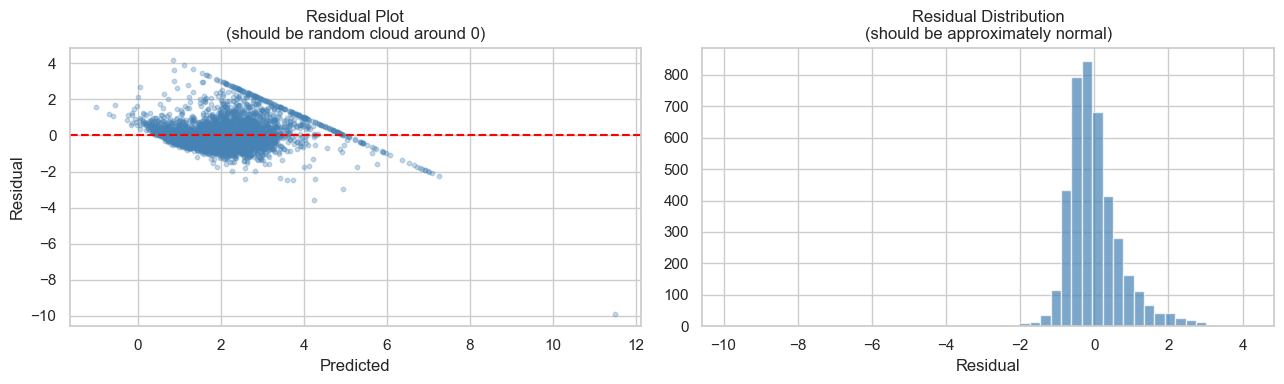

In [6]:
housing = fetch_california_housing()
Xh = pd.DataFrame(housing.data, columns=housing.feature_names)
yh = housing.target

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)

reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
reg_pipe.fit(Xh_train, yh_train)
yh_pred = reg_pipe.predict(Xh_test)

mae  = mean_absolute_error(yh_test, yh_pred)
rmse = np.sqrt(mean_squared_error(yh_test, yh_pred))
r2   = r2_score(yh_test, yh_pred)

print("Ridge Regression on California Housing:")
print(f"  MAE:  {mae:.4f}  (median error = ${mae*100_000:,.0f} off from actual house price)")
print(f"  RMSE: {rmse:.4f}  (more sensitive to large errors than MAE)")
print(f"  R²:   {r2:.4f}  (model explains {r2:.1%} of price variance)")

# Residual plot — should show no patterns if model is good
residuals = yh_test - yh_pred
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.scatter(yh_pred, residuals, alpha=0.3, color='steelblue', s=10)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Residual')
ax1.set_title('Residual Plot\n(should be random cloud around 0)')

ax2.hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax2.set_xlabel('Residual')
ax2.set_title('Residual Distribution\n(should be approximately normal)')

plt.tight_layout()
plt.show()

## 5. Learning Curves — Diagnosing Underfitting vs Overfitting

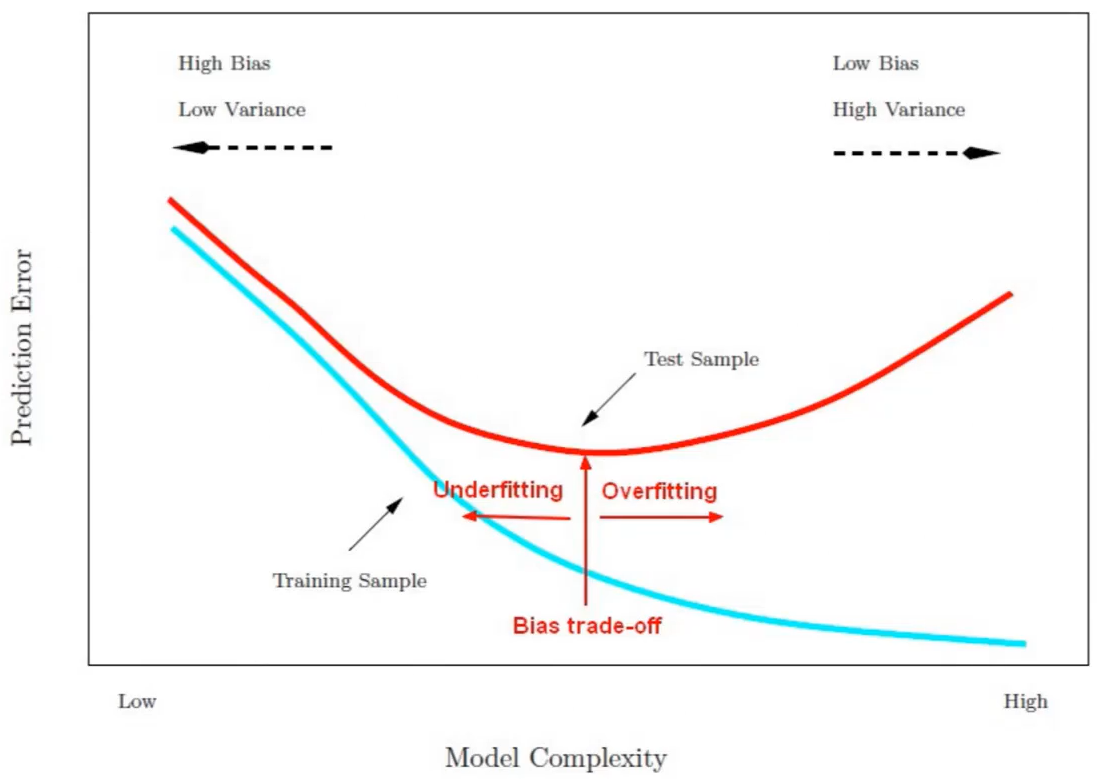

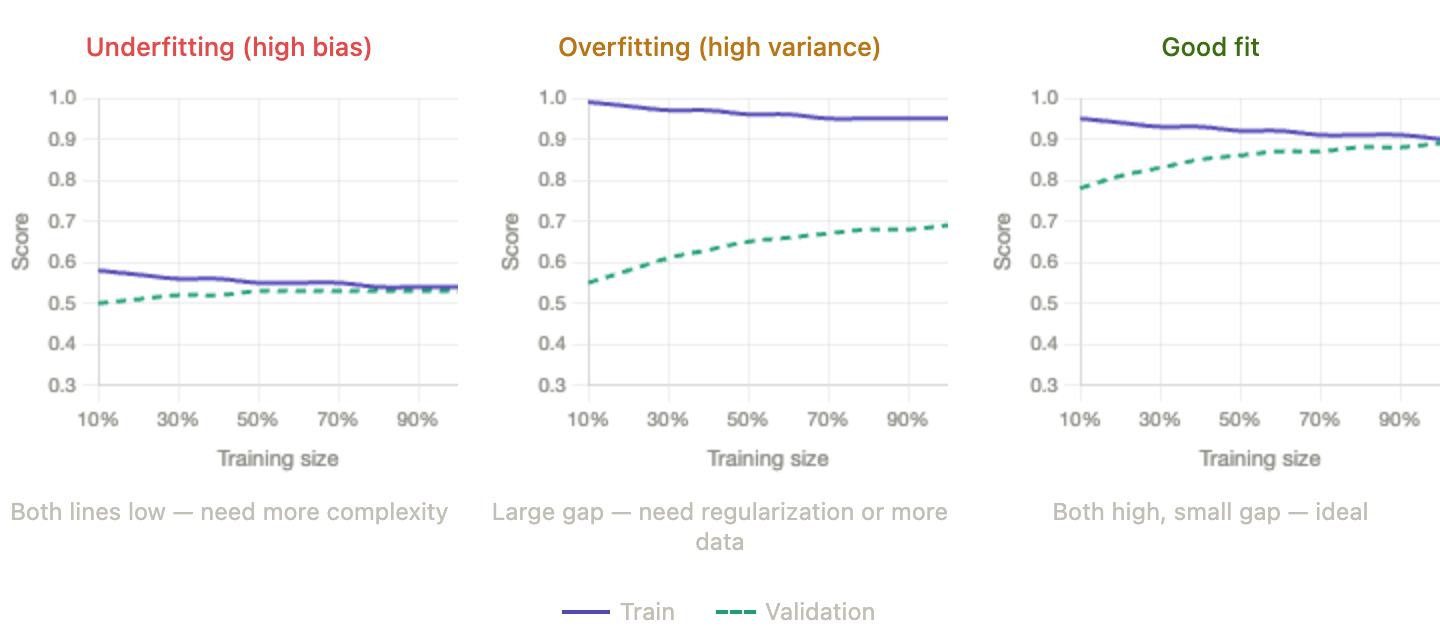


A learning curve plots model performance against training set size. As you feed the model more data, you watch how training score and validation score evolve — the gap and level between them tells you exactly what's wrong.

---

### How to Read Them

```
X-axis: number of training samples used
Y-axis: model score (accuracy, R², etc.)

Two lines:
  - Training score   → how well model fits data it was trained on
  - Validation score → how well model generalizes to unseen data
```

A well-fitted model has both lines **high and close together**.

---

### Underfitting (High Bias)

The model is too simple to capture the pattern in the data.

```
Score ↑
 1.0 |
 0.8 |
 0.6 |──────────── train ─────────────    ← train score low and flat
 0.5 |──────────── validation ──────────  ← val score equally low
 0.4 |
      └─────────────────────────────────→ training size
```

**What you see:**
- Both training and validation scores are **low**
- The gap between them is **small** — model performs equally poorly on both
- Adding more data **does not help** — the lines stay flat

**Why it happens:** Model doesn't have enough capacity to learn the pattern. A linear model trying to fit a curved relationship, for example.

**Fix:**
- Use a more complex model
- Add more features
- Reduce regularization

---

### Overfitting (High Variance)

The model memorized the training data but fails to generalize.

```
Score ↑
 1.0 |─────────────── train ────────────  ← train score very high
 0.8 |
 0.6 |
 0.5 |──────────── validation ──────────  ← val score much lower
 0.4 |
      └─────────────────────────────────→ training size
```

**What you see:**
- Training score is **high**, validation score is **low**
- Large **gap** between the two lines
- Adding more data **slowly closes the gap** — val score climbs as size increases

**Why it happens:** Model is too complex relative to the amount of data. It learns noise and specific training examples instead of general patterns.

**Fix:**
- Add regularization (Ridge, Lasso, dropout)
- Use a simpler model
- Get more training data
- Use cross-validation

---

### Well-Fitted Model

```
Score ↑
 1.0 |
 0.9 |──────────── train ─────────────
 0.8 |──────────── validation ─────── ← both high, small gap
 0.7 |
      └─────────────────────────────→ training size
```

Both scores are high and converge close together. This is what you're aiming for.

---

### Diagnosis Cheat Sheet

| What you see | Problem | Fix |
|-------------|---------|-----|
| Both scores low, small gap | Underfitting (high bias) | More complexity, more features |
| Train high, val low, large gap | Overfitting (high variance) | Regularization, more data, simpler model |
| Both scores high, small gap | Good fit | Ship it |
| Val score jumps around | Too little data | Collect more data |

---

### Key Insight

> More data only helps overfitting — it cannot fix underfitting. If your model is too simple, no amount of data will make it perform better. Fix the model first, then worry about data size.

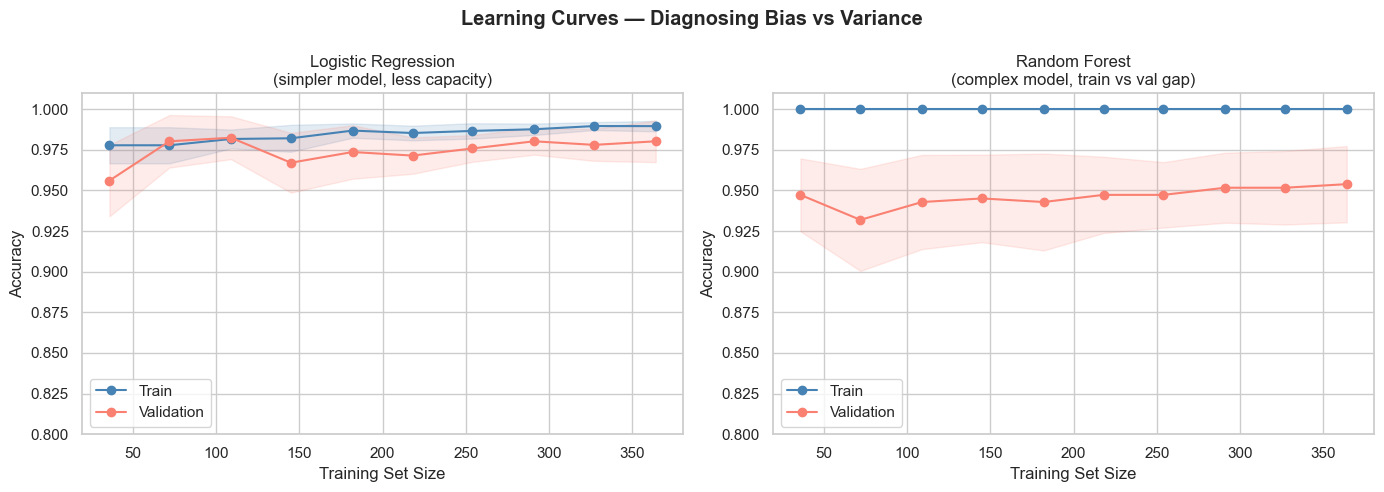

Gap between train/val = variance (overfitting). Both low = bias (underfitting).


In [10]:
def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='salmon', label='Validation')
    ax.fill_between(train_sizes, 
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='salmon')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0.8, 1.01)

pipe_log = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
pipe_rf  = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=100, random_state=42))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(pipe_log, X_train, y_train, 'Logistic Regression\n(simpler model, less capacity)', ax1)
plot_learning_curve(pipe_rf, X_train, y_train, 'Random Forest\n(complex model, train vs val gap)', ax2)

plt.suptitle('Learning Curves — Diagnosing Bias vs Variance', fontweight='bold')
plt.tight_layout()
plt.show()
print("Gap between train/val = variance (overfitting). Both low = bias (underfitting).")




## 6. GridSearchCV — Exhaustive Hyperparameter Search

`GridSearchCV` tries **every combination** of hyperparameters you specify and finds the best one using cross-validation.

### How GridSearchCV Works Internally

```
param_grid = {'C': [0.01, 0.1, 1, 10], 'kernel': ['rbf', 'linear']}

(C=0.01, kernel=rbf)    → 5-fold CV → mean score
(C=0.01, kernel=linear) → 5-fold CV → mean score
(C=0.1,  kernel=rbf)    → 5-fold CV → mean score
(C=0.1,  kernel=linear) → 5-fold CV → mean score
... 8 combinations × 5 folds = 40 model fits

→ pick the combination with the highest mean CV score → best_params_
```

---

### The `model__` Prefix Inside a Pipeline

When your estimator lives inside a Pipeline, hyperparameter names need a prefix — the step name + double underscore + param name.

```python
# Standalone model:
param_grid = {'C': [0.1, 1, 10]}

# Same model inside a Pipeline step named 'model':
param_grid = {'model__C': [0.1, 1, 10]}
#              ^^^^^^
#         step name + __ + param name
```

This tells GridSearchCV which step the parameter belongs to. Without it, sklearn doesn't know where to look and throws an error.

---

### What You Get Back

```python
grid.best_params_     # {'C': 1, 'kernel': 'rbf'}   — best combination found
grid.best_score_      # 0.923  — mean CV score of that combination
grid.best_estimator_  # the actual fitted model with best params applied
grid.cv_results_      # full breakdown for every combination tried
```

`best_estimator_` is already fitted — you can call `.predict()` on it directly without refitting.

---

### When Grid Search Gets Slow

Each new parameter multiplies the total fits:

```
3 params × 5 values × 5 folds =   125 × 5 =   625 fits
4 params × 5 values × 5 folds =   625 × 5 = 3,125 fits
5 params × 5 values × 5 folds = 3,125 × 5 = 15,625 fits
```

Grows exponentially. This is why `RandomizedSearchCV` exists — same idea, but samples a fixed number of random combinations instead of trying all of them.

In [13]:
from sklearn.calibration import CalibratedClassifierCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CalibratedClassifierCV(SVC(), ensemble=False))
])

# model__estimator__ prefix because SVC is nested inside CalibratedClassifierCV
param_grid = {
    'model__estimator__C':      [0.01, 0.1, 1, 10, 100],
    'model__estimator__kernel': ['rbf', 'linear'],
    'model__estimator__gamma':  ['scale', 'auto'],
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Test  ROC-AUC:   {roc_auc_score(y_test, grid_search.predict_proba(X_test)[:,1]):.4f}")
print(f"\nTotal fits: {len(param_grid['model__estimator__C']) * len(param_grid['model__estimator__kernel']) * len(param_grid['model__estimator__gamma'])} combinations × 5 folds = {len(param_grid['model__estimator__C']) * len(param_grid['model__estimator__kernel']) * len(param_grid['model__estimator__gamma']) * 5} fits")

# Show top configurations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_model__estimator__C', 'param_model__estimator__kernel', 'param_model__estimator__gamma', 'mean_test_score', 'std_test_score']]
results_df = results_df.sort_values('mean_test_score', ascending=False)
print("\nTop 5 configurations:")
print(results_df.head(5).to_string(index=False))


Best parameters: {'model__estimator__C': 0.1, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'linear'}
Best CV ROC-AUC: 0.9957
Test  ROC-AUC:   0.9937

Total fits: 20 combinations × 5 folds = 100 fits

Top 5 configurations:
 param_model__estimator__C param_model__estimator__kernel param_model__estimator__gamma  mean_test_score  std_test_score
                       0.1                         linear                         scale         0.995666        0.004622
                       0.1                         linear                          auto         0.995666        0.004622
                       1.0                            rbf                          auto         0.995562        0.004758
                       1.0                            rbf                         scale         0.995562        0.004758
                       1.0                         linear                         scale         0.994737        0.007293


## 7. RandomizedSearchCV — Smarter Search for Large Spaces

For larger hyperparameter spaces, `RandomizedSearchCV` randomly samples a fixed number of combinations instead of trying all of them.

---

### Grid vs Random — The Key Difference

```
Grid Search:    tries every combination — guaranteed to find the best in your grid
Random Search:  samples n_iter random combinations — faster, covers more ground
```

Why random often wins: in most problems, **one or two hyperparameters matter far more than the rest**. Grid search wastes time on the unimportant ones. Random search spreads trials across all dimensions and finds good regions faster.

```
Grid search with 2 params, 5 values each:
● ● ● ● ●
● ● ● ● ●     tries all 25 — most in unimportant regions
● ● ● ● ●
● ● ● ● ●
● ● ● ● ●

Random search, 10 samples:
  ●     ●
●    ●        hits more unique values of each dimension
   ●    ●     even with fewer total tries
●    ●
  ●     ●
```

---

In [14]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Distributions, not lists — random search samples from them
param_dist = {
    'model__n_estimators':      randint(50, 500),       # sample integers from this range
    'model__max_depth':         [None, 3, 5, 7, 10, 15],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10),
    'model__max_features':      uniform(0.1, 0.9),      # fraction of features to consider
}

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=50,           # try 50 random combinations (vs all combos in Grid)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rand_search.fit(X_train, y_train)

print(f"Best parameters: {rand_search.best_params_}")
print(f"Best CV ROC-AUC:  {rand_search.best_score_:.4f}")
print(f"Test  ROC-AUC:    {roc_auc_score(y_test, rand_search.predict_proba(X_test)[:,1]):.4f}")
print(f"\nOnly 50 fits vs potentially thousands for a full grid search.")

Best parameters: {'model__max_depth': None, 'model__max_features': np.float64(0.3401029128477565), 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 269}
Best CV ROC-AUC:  0.9910
Test  ROC-AUC:    0.9924

Only 50 fits vs potentially thousands for a full grid search.


## 8. Hyperparameter Tuning Strategy

Don't tune blindly. There's a logical order:

```
1. Start with defaults — get a baseline
2. Coarse search — wide ranges, random search, find the region
3. Fine search — narrow grid search around the best region
4. Evaluate on test set — exactly ONCE at the end
```

**What to tune and in what order for Random Forests:**

| Parameter | Impact | Default | Typical range |
|-----------|--------|---------|---------------|
| `n_estimators` | Accuracy ↑ with more trees (diminishing returns) | 100 | 100–500 |
| `max_depth` | Controls overfitting | None (full) | 3–15 or None |
| `min_samples_split` | Regularization — more = less overfit | 2 | 2–20 |
| `max_features` | Diversity between trees | 'sqrt' | 'sqrt', 'log2', 0.1–0.9 |

**For Logistic Regression:** Tune `C` (inverse regularization strength) first — it dominates everything else.

### Practical Tips

- Always set `random_state` — makes results reproducible
- Use `n_jobs=-1` — parallel fitting across all CPU cores
- After coarse search, zoom in: if best `max_depth` was 7, fine search `[5, 6, 7, 8, 9]`
- A small improvement in CV score may not be worth the tuning time — know when to stop

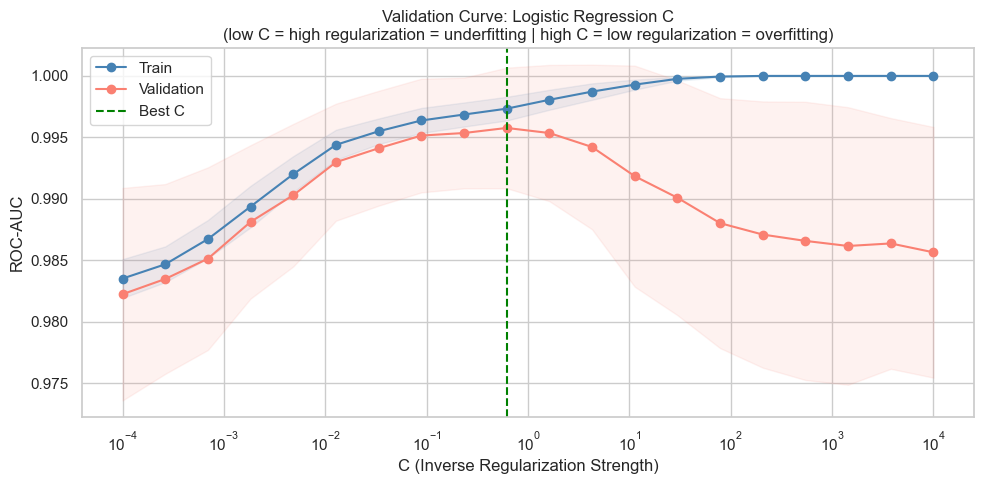

Best C: 0.6158


In [15]:
# Validation curve: show how one hyperparameter affects train vs val score
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
C_values = np.logspace(-4, 4, 20)

train_scores, val_scores = validation_curve(
    pipe, X_train, y_train,
    param_name='model__C',
    param_range=C_values,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(C_values, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train')
ax.semilogx(C_values, val_scores.mean(axis=1), 'o-', color='salmon', label='Validation')
ax.fill_between(C_values, train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.1, color='steelblue')
ax.fill_between(C_values, val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.1, color='salmon')
ax.axvline(C_values[val_scores.mean(1).argmax()], color='green', linestyle='--', label='Best C')
ax.set_xlabel('C (Inverse Regularization Strength)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation Curve: Logistic Regression C\n(low C = high regularization = underfitting | high C = low regularization = overfitting)')
ax.legend()
plt.tight_layout()
plt.show()

best_C = C_values[val_scores.mean(1).argmax()]
print(f"Best C: {best_C:.4f}")

In [16]:
# Final comparison: default model vs tuned model on TEST SET
default_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])
default_pipe.fit(X_train, y_train)

tuned_model = rand_search.best_estimator_

print("Final Test Set Evaluation (reported only ONCE):")
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 60)
for name, model in [('Default RF', default_pipe), ('Tuned RF (RandomSearch)', tuned_model)]:
    yp = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:, 1]
    print(f"{name:<25} {accuracy_score(y_test, yp):>10.4f} {f1_score(y_test, yp):>10.4f} {roc_auc_score(y_test, yprob):>10.4f}")

Final Test Set Evaluation (reported only ONCE):
Model                       Accuracy         F1    ROC-AUC
------------------------------------------------------------
Default RF                    0.9561     0.9655     0.9939
Tuned RF (RandomSearch)       0.9561     0.9655     0.9924


### Hyperparameter tuning doesn't always help. On easy datasets with good defaults, it can be a waste of time or even slightly hurt. Tuning matters most on complex datasets where defaults leave clear room for improvement. To see a more dramatic difference, you'd need a noisier, higher-dimensional dataset like a Kaggle competition dataset.

## Practice

**1.** Your model has 98% train accuracy and 72% test accuracy. What does this tell you, and what are two things you would try to fix it?  

=> It means the model is overfitting(high variance), the model is not performing well on unseen(test) data. For this, general fix is to increase the training data size. We can also add regularization.

**2.** You have 1000 samples, 950 class-0, 50 class-1. You train a model that predicts all class-0. What is the accuracy? Why is this model useless, and what metric should you use instead?  

=> If the model predicts all class-0 then the accuracy is (950/1000) * 100 = 95 percent.
The model is useless because it never predicts class-1 at all — it has 0% recall for the minority class. It learned nothing, just exploited the class imbalance. Use **F1 score on the minority class** or **ROC-AUC** instead — both measure ranking and balance quality, not just raw correctness.

**3.** In `GridSearchCV`, why must you use cross-validation instead of a single train/val split for hyperparameter selection?  

=> A single val split is unreliable because the result depends on *which samples happened to land in the validation set*. If easy samples ended up there by chance, a mediocre hyperparameter looks great. If hard samples ended up there, a good hyperparameter looks bad. Either way, you're picking based on luck, not true performance.

Cross-validation fixes this by rotating the validation set across k folds — every sample gets tested exactly once. The final score is the average across all folds, so one lucky or unlucky split can't dominate the result. This gives a stable, trustworthy estimate of which hyperparameter actually generalizes.

**4.** Your GridSearchCV tests 1000 combinations with 5-fold CV. How many total model fits does this require? At 2 seconds per fit, how long does this take?  

=> For 1000 combinations with 5-fold CV, it takes 1000 * 5 = 5000 model fits. At 2 seconds per fit, it takes 5000 * 2 secs = 10000 secs.

**5.** After tuning, your validation ROC-AUC is 0.97 but test ROC-AUC is 0.84. What likely happened and how do you prevent it?  

=> This is **overfitting to the validation set**. When you search through hundreds or thousands of hyperparameter combinations, you are repeatedly evaluating on the same validation fold. Eventually you find a combination that scores well on that specific slice of data — not because it genuinely generalizes, but because it got lucky on those particular samples. The more combinations you try, the more likely this is to happen.

The test set has never been seen before, so it reveals the true performance — 0.84, not 0.97.

Fixes:
- Keep a **held-out test set** that is never touched during tuning — evaluate on it exactly once at the very end
- Use **nested cross-validation** — the outer loop estimates true generalization, the inner loop handles hyperparameter search independently
- Be suspicious whenever validation score is significantly higher than test score — it almost always means the validation set was overused

---


**Q3 — Single split vs cross-validation:**

Imagine you have a class of 30 students and you want to test which teaching method is best. You split them into 25 for teaching and 5 for testing.

Problem — those 5 students might be the smartest in the class by chance. Your method looks great, but it's because of *who* ended up in the test group, not because the method is actually better.

Cross-validation fixes this by rotating the test group:

```
Round 1: students 1–5   are the test group
Round 2: students 6–10  are the test group
Round 3: students 11–15 are the test group
...and so on
```

Every student gets tested at some point. The final score is the average — much harder to get lucky.

Same idea with data. A single val split might accidentally put easy samples in validation. Cross-validation rotates through all the data so luck averages out.

---

**Q5 — Overfitting to the validation set:**

Think of it like a practice exam. You take the same practice exam 1000 times, tweaking your study method each time based on those specific questions. Eventually you score 97% — but not because you truly understand the subject, just because you've seen those exact questions so many times.

Then you sit the real exam (test set) — 84%. The real exam has questions you haven't over-optimized for.

That's exactly what happens with too many hyperparameter combinations on the same validation fold — you're not finding what genuinely works, you're finding what works for *that specific slice of data*.


## Key Takeaways

- **Three splits:** train (learn) → validation (tune) → test (report once, honestly)
- **Cross-validation** averages over multiple splits — always prefer it over a single val split
- **Accuracy on imbalanced data is meaningless** — use F1, ROC-AUC, or precision/recall
- **Confusion matrix** shows *which* mistakes you're making — crucial for domain decisions
- **Learning curves** diagnose the problem: bias (both low) vs variance (train >> val)
- **GridSearch** = exhaustive, for small spaces; **RandomSearch** = faster, for large spaces
- **Tune in order:** coarse random search → narrow grid search → test set once at the end
- **The test set is sacred** — every time you look at it and adjust, your evaluation is corrupted